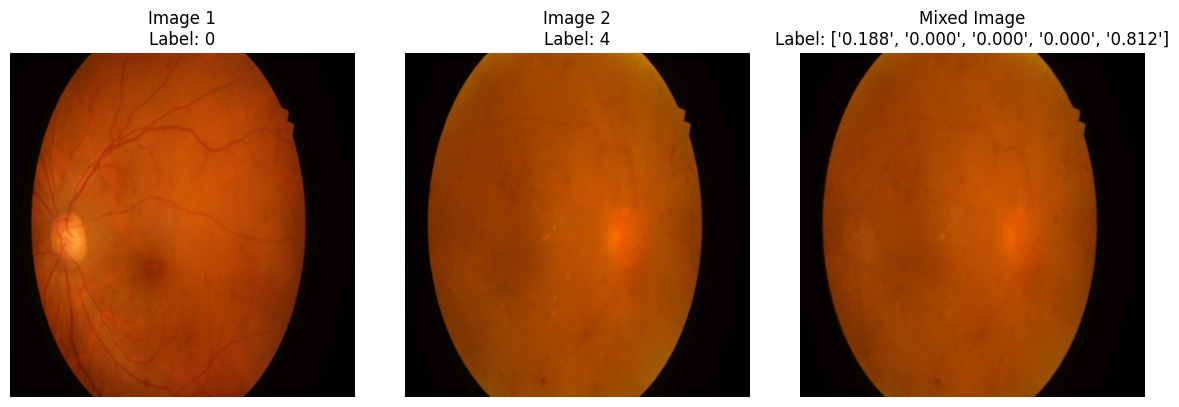

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from src.dataset_csv import ImageCSVDataset

# Define a one-hot encoding function
def onehot(label, n_classes):
    return torch.zeros(label.size(0), n_classes).scatter_(1, label.view(-1, 1).long(), 1)

# Define the Mixup function
def mixup(data1, data2, targets1, targets2, alpha, n_classes):
    targets1 = onehot(targets1, n_classes)
    targets2 = onehot(targets2, n_classes)

    lam = np.random.beta(alpha, alpha)
    mixed_data = data1 * lam + data2 * (1 - lam)
    mixed_targets = targets1 * lam + targets2 * (1 - lam)

    return mixed_data, mixed_targets


# Dataset paths
l_train_dataset_path = '/cluster/tufts/hugheslab/datasets/IDRID/Labels/train.csv'
root_dataset_path = '/cluster/tufts/hugheslab/datasets/IDRID/Images'

# Load IDRID dataset
transform = transforms.Compose([
    transforms.Resize((384, 384)),  # Resize for visualization
    transforms.ToTensor(),       # Convert to tensor
])
train_dataset = ImageCSVDataset(csv_file=l_train_dataset_path, root_dir=root_dataset_path, transform=transform)

# Get two images and their labels
img1, label1 = train_dataset[0]
img2, label2 = train_dataset[1]

# Ensure images and labels are tensors
label1 = torch.tensor([label1])  # Convert to tensor and batchify
label2 = torch.tensor([label2])

# Apply Mixup
alpha = 0.4
n_classes = 5
img1 = img1.unsqueeze(0)  
img2 = img2.unsqueeze(0)  
mixed_image, mixed_label = mixup(img1, img2, label1, label2, alpha, n_classes)

# Convert images for visualization
to_pil = transforms.ToPILImage()
img1_vis = to_pil(img1.squeeze(0))
img2_vis = to_pil(img2.squeeze(0))
mixed_image_vis = to_pil(mixed_image.squeeze(0))

# Plot images and labels
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Original Image 1
ax[0].imshow(img1_vis)
ax[0].set_title(f"Image 1\nLabel: {label1.item()}")
ax[0].axis("off")

# Original Image 2
ax[1].imshow(img2_vis)
ax[1].set_title(f"Image 2\nLabel: {label2.item()}")
ax[1].axis("off")

# Mixed Image
mixed_label_rounded = [f"{val:.3f}" for val in mixed_label.squeeze(0).tolist()]
ax[2].imshow(mixed_image_vis)
ax[2].set_title(f"Mixed Image\nLabel: {mixed_label_rounded}")
ax[2].axis("off")

plt.tight_layout()
plt.show()
